In [ ]:
import torch
print(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
import torchaudio
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import torch.nn as nn


from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Audio


cuda


# Dataset creation

In [2]:
class WavDataset(Dataset):
    """
    A dataset that lazily loads WAV files from a directory.
    
    Args:
        dataset_dir (str or Path): Path to the dataset folder.
    
    Returns:
        waveform (torch.Tensor): Tensor containing the waveform.
        filename (str): Name of the file without the extension.
        
    """
    def __init__(self, dataset_dir):
        dataset_dir = Path(dataset_dir)
        self.wav_files = sorted(dataset_dir.iterdir())

    def __len__(self):
        return len(self.wav_files)
    
    def __getitem__(self, index):
        wav_path = self.wav_files[index]
        waveform, _ = torchaudio.load(wav_path)
        filename = wav_path.stem
        return waveform, filename



## Dataset analysis
| Training Dataset (s) | Test Dataset (s) | Range | Noise |
| - | - | - | - |
| Max: 15.11 <br> Min: 1.09 <br> Avg: 2.92 | Max: 9.76 <br> Min: 1.23 <br> Avg: 2.51 | Waveforms normalized to [-1,1] | Noise is real, not randomly generated|

#### Conclusion 
Apply padding to 20 s (20*44000=880000), no need to normalize data, the model must be able to handle this type of noise.

In [ ]:
# dataset_dir = "../data/clean_trainset_28spk_wav"
# dataset = WavDataset(dataset_dir)
# loader = DataLoader(dataset, batch_size=1, num_workers=1,shuffle=False)

# def analysis(x):
#     return len(x[0].squeeze())/48000

# lengths = []
# for batch in loader:
#     lengths.append(analysis(batch))

# print('Training Dataset')
# print('Max length',max(lengths))
# print('Min length',min(lengths))
# print('Avg length',sum(lengths)/len(lengths))

Training Dataset
Max length 15.1120625
Min length 1.092375
Avg length 2.921571917487614


In [ ]:
# dataset_dir = "../data/clean_testset_wav"
# dataset = WavDataset(dataset_dir)
# loader = DataLoader(dataset, batch_size=1, num_workers=1,shuffle=False)

# lengths = []
# for batch in loader:
#     lengths.append(analysis(batch))
    
# print('Test Dataset')
# print('Max length',max(lengths))
# print('Min length',min(lengths))
# print('Avg length',sum(lengths)/len(lengths))

Test Dataset
Max length 9.768854166666667
Min length 1.2375625
Avg length 2.51460007079288


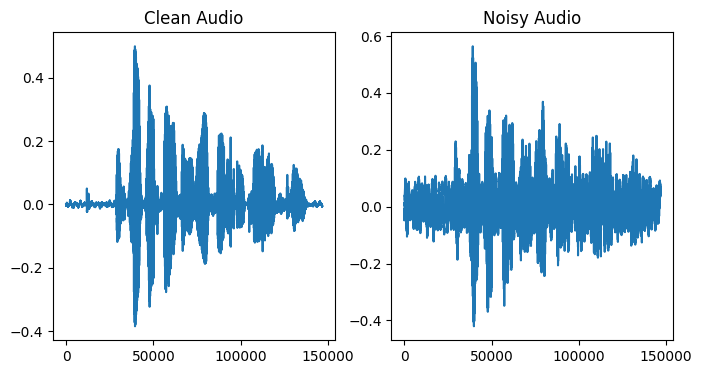

In [86]:
clean_dataset_dir = "../data/clean_testset_wav"
clean_dataset = WavDataset(clean_dataset_dir)
clean_wav = clean_dataset[0][0].squeeze()

noisy_dataset_dir = "../data/noisy_testset_wav"
noisy_dataset = WavDataset(noisy_dataset_dir)
noisy_wav = noisy_dataset[0][0].squeeze()

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(clean_wav)
ax[0].set_title("Clean Audio")

ax[1].plot(noisy_wav)
ax[1].set_title("Noisy Audio")

plt.show()

display(Audio(clean_wav, rate=44000))
display(Audio(noisy_wav, rate=44000))

## Train/Val/Test Split and Dataloader Creation


In [11]:
def collate_fn(batch):
    waveforms, filenames = zip(*batch)

    # Pad waveforms
    waveforms = [w.squeeze() for w in waveforms]  # shape (1,1,n) -> (n,)
    # Define padded matrix
    batch_size, target_len = len(batch), 20*44000
    padded_waveforms = torch.zeros(batch_size, target_len)
    # Add waveforms to padded matrix
    for i, w in enumerate(waveforms):
        length = min(w.shape[0], target_len) # will truncate samples larger than target_len
        padded_waveforms[i, :length] = w[:length]
    waveforms = torch.nn.utils.rnn.pad_sequence(padded_waveforms, batch_first=True)

    return waveforms, filenames


# SPLITTING
# Be sure to tune these parameters!! 
batch_size = 32
num_workers = 8
SAMPLE_SIZE_COMPLETE = 11573 # In this case, it's sample size of the 28spk dataset
sample_size = 128 # This is the actual parameters that dictates the sample size used in training
torch.manual_seed(42)

# Train/Val split
# 90/10 split
train_size = int(0.9 * sample_size)

# To solve misaligment issues, use indices to divide into subsets
indices = torch.randperm(SAMPLE_SIZE_COMPLETE) # get a perm from the complete dataset
train_indices = indices[:train_size]
val_indices = indices[train_size:]

noisy_dataset = WavDataset('../data/noisy_trainset_28spk_wav')
clean_dataset = WavDataset('../data/clean_trainset_28spk_wav')
x_train = Subset(noisy_dataset, train_indices)
x_val = Subset(noisy_dataset, val_indices)
y_train = Subset(clean_dataset, train_indices)
y_val = Subset(clean_dataset, val_indices)

x_train = DataLoader(
    x_train,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn
)

x_val = DataLoader(
    x_val,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn
)

y_train = DataLoader(
    y_train,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn
)

y_val = DataLoader(
    y_val,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn
)

# Test split
x_test = DataLoader(
    WavDataset('../data/noisy_testset_wav'),
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn
)

y_test = DataLoader(
    WavDataset('../data/clean_testset_wav'),
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn
)

# check alignment   
print(next(iter(x_train))[1])
print(next(iter(y_train))[1])fsdf
        

('p233_180', 'p239_332', 'p274_010', 'p282_033', 'p236_412', 'p273_175', 'p231_282', 'p278_378', 'p269_322', 'p227_275', 'p273_222', 'p286_339', 'p244_279', 'p286_150', 'p243_151', 'p267_077', 'p254_303', 'p273_002', 'p287_094', 'p273_395', 'p267_051', 'p259_113', 'p231_067', 'p258_307', 'p276_459', 'p250_335', 'p270_135', 'p273_181', 'p258_147', 'p236_170', 'p282_209', 'p287_256')
('p233_180', 'p239_332', 'p274_010', 'p282_033', 'p236_412', 'p273_175', 'p231_282', 'p278_378', 'p269_322', 'p227_275', 'p273_222', 'p286_339', 'p244_279', 'p286_150', 'p243_151', 'p267_077', 'p254_303', 'p273_002', 'p287_094', 'p273_395', 'p267_051', 'p259_113', 'p231_067', 'p258_307', 'p276_459', 'p250_335', 'p270_135', 'p273_181', 'p258_147', 'p236_170', 'p282_209', 'p287_256')


# Denoising

In [ ]:
class Wave_UNet(nn.Module):
    """
    Implements Wave-U-Net, meaning it employs Conv1D in a 
    encode-decode structure that takes raw audio and denoises it.
    You can see it employs Batch Normalization, ReLU;
    but most importantly, Conv1D is used in both the encoder and decoder
    and doesn't reduce dimensionality by itself in order
    to avoid artifacting. The downsizing is handled by MaxPool1d and
    the upsizing is handled by Upsample using linear interpolation.
    Between both blocks there's a 15 kernel size convolution and 
    a 1 kernel size convolution at the end of the process, breaking
    the kernel size simmetry (See how in the __init__ the decoder for loop
    is one shorter than the encoder).
    """

    class EncoderBlock(nn.Module):
        def __init__(self, in_channels, out_channels, kernel_size=15, padding=7):
            super().__init__()
            self.conv = nn.Conv1d(in_channels, out_channels, 
                                  kernel_size=kernel_size, padding=padding)
            self.bn = nn.BatchNorm1d(out_channels)
            self.relu = nn.ReLU()
            self.pool = nn.MaxPool1d(2)

        def forward(self, x):
            x = self.conv(x)
            x = self.bn(x)
            x = self.relu(x)
            skip = x  # for skip connection
            x = self.pool(x)
            return x, skip
        
    class DecoderBlock(nn.Module):
        def __init__(self, in_channels, skip_channels, out_channels, kernel_size=5, padding=2):
            super().__init__()
            self.upsample = nn.Upsample(scale_factor=2, mode='linear', align_corners=True)
            self.conv = nn.Conv1d(in_channels+skip_channels, out_channels, 
                                    kernel_size=kernel_size, padding=padding) 
            self.bn = nn.BatchNorm1d(out_channels)
            self.relu = nn.ReLU()
            
        def forward(self, x, skip):
            x = self.upsample(x)
            x = torch.cat([x, skip], dim=1)
            x = self.conv(x)
            x = self.bn(x)
            x = self.relu(x)
            return x
        
    def __init__(self, depth=4, base_filters=24):
            super().__init__()

            # Encoder
            self.encoders = nn.ModuleList()
            in_ch = 1 
            for i in range(depth): # 0 -> 3
                out_ch = base_filters * (i + 1)
                self.encoders.append(self.EncoderBlock(in_ch, out_ch))
                in_ch = out_ch
                
            self.mid_conv = nn.Conv1d(in_ch, in_ch, kernel_size=15, padding=7)
            
            # Decoder
            self.decoders = nn.ModuleList()
            for i in range(depth-1, 0, -1): # 3 -> 1
                skip_ch = base_filters * i # take into account the skip connections
                out_ch = base_filters * i
                self.decoders.append(self.DecoderBlock(in_ch, skip_ch, out_ch))
                in_ch = out_ch
            
            self.final_conv = nn.Conv1d(in_ch, 1, 1, kernel_size=1, padding=0)
         
    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x, skip = enc(x)
            skips.append(skip)
    
        x = self.mid_conv(x)

        for dec in self.decoders:
            skip = skips.pop()
            x = dec(x, skip)
        
        x = self.final_conv(x)

        return x

        

NameError: name 'nn' is not defined